## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the new dataset

In [2]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Final Dataset/Dataset 3 - IN - 2024/HR-Preg .csv'  # Update with your file path
df = pd.read_csv(file_path)

# For Anemia - {None : 0, Minimal : 1 , Medium : 2}
# For Jaundice - {None : 0, Minimal : 1, Medium : 2}
# For Jaundice - {None : 0, Minimal : 1, Medium : 2 , Higher : 3}

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
          Name  Age Gravida TiTi Tika Gestation Period Weight Height  \
0    Rituporna   18     1st       1st          38 week  50 kg  5.3''   
1        Moina   25     2nd       2nd          38 week  60 kg  5.2''   
2       Rabeya   20     1st       1st          30 week  55 kg  5.0''   
3       Shorna   22     1st       3rd          35 week  51 kg  5.4''   
4  Tania Akter   20     1st       2nd          30 week  53 kg  5.2''   

   Systolic Pressure  Diastolic Pressure  Anemia  Jaundice Fetal Position  \
0                100                  60       0         0         Normal   
1                100                  70       0         0         Normal   
2                100                  60       0         0         Normal   
3                110                  65       0         0         Normal   
4                100                  55       0         0         Normal   

  Fetal Movements Fetal Heartbeat  Urine Test Albumin Urine Test Sugar  \
0

# Without SMOTE

## Applying ANN

### Without Feature Selection

In [ ]:
# SHOWING IMPLEMENTATION OF ANN USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to Categorical Columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Convert string values to numbers
    label_encoders[col] = le

# Define the ANN function
def ann_classification(data, target_col, features, epochs=80, batch_size=16):

    # Select the features and target variable
    X = data[features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Scale the data using StandardScaler (Only Numeric Columns)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Specify the target column
target_column = 'High-Risk Pregnancy'

# Use all features except the target column
all_features = df.columns.drop([target_column])

# Apply ANN on the dataset using all features
ann_model = ann_classification(df, target_column, all_features, epochs=80, batch_size=16)


Epoch 1/80


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5361 - loss: 0.6843 - val_accuracy: 0.6313 - val_loss: 0.6196
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7320 - loss: 0.5229 - val_accuracy: 0.7500 - val_loss: 0.5274
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8018 - loss: 0.4380 - val_accuracy: 0.7812 - val_loss: 0.4787
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3816 - val_accuracy: 0.7937 - val_loss: 0.4581
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8389 - loss: 0.3194 - val_accuracy: 0.7937 - val_loss: 0.4704
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8516 - loss: 0.3009 - val_accuracy: 0.7875 - val_loss: 0.4332
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8473 - loss: 0.3049 - val_accuracy: 0.7937 - val_loss: 0.4257
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8732 - loss: 0.2640 - val_accuracy: 0.8062 - val_loss: 0.3752
Ep

In [ ]:
df

,Name,Age,Gravida,TiTi Tika,Gestation Period,Weight,Height,Systolic Pressure,Diastolic Pressure,Anemia,Jaundice,Fetal Position,Fetal Movements,Fetal Heartbeat,Urine Test Albumin,Urine Test Sugar,VDRL,HRsAG,High-Risk Pregnancy
0,214,18,0,0,10,2,3,100,60,0,0,1,0,3,0,1,0,0,1
1,149,25,1,1,10,9,2,100,70,0,0,1,0,2,0,1,1,0,0
2,198,20,0,0,6,6,0,100,60,0,0,1,0,0,0,1,0,0,1
3,294,22,0,2,8,3,4,110,65,0,0,1,0,2,0,1,1,0,1
4,324,20,0,1,6,5,2,100,55,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,208,22,0,0,0,1,6,90,60,0,0,1,0,4,0,1,1,0,1
994,6,22,0,1,6,0,3,110,80,0,0,0,0,3,0,1,0,0,0
995,196,19,0,2,6,2,2,100,70,0,0,1,0,3,0,1,1,0,1
996,240,30,1,1,6,1,1,90,60,0,0,1,0,2,0,1,0,0,1


### With FS

In [3]:
# Load required libraries
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.metrics import accuracy_score, classification_report


In [4]:
# Convert all object columns to numerical using factorize
for column in df.select_dtypes(include=['object']):
    df[column], _ = df[column].factorize()

# Separate features and target
X = df.drop('High-Risk Pregnancy', axis=1)  # Update with actual target column
y = df['High-Risk Pregnancy']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
X_train = pd.DataFrame(scale(X_train), columns=X.columns)
X_test = pd.DataFrame(scale(X_test), columns=X.columns)

# Compute initial Mutual Information Scores
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_sorted_indices = np.argsort(mi)[::-1]

# Select top 50% features
num_features = len(mi_sorted_indices)
best_50_percent_indices = mi_sorted_indices[:num_features // 2]
excluded_features_indices = mi_sorted_indices[num_features // 2:]

# Convert indices to column names
best_features = X_train.columns[best_50_percent_indices].tolist()
excluded_features = X_train.columns[excluded_features_indices].tolist()

# Iterative feature selection
iterations = 15
for i in range(iterations):
    improved = False
    print(f"Iteration {i+1}:")

    for j in range(len(excluded_features)):
        for k in range(len(best_features)):
            # Swap one excluded with one included feature
            temp_best_features = best_features.copy()
            temp_excluded_features = excluded_features.copy()

            feature_to_add = excluded_features[j]
            feature_to_remove = best_features[k]

            temp_best_features.append(feature_to_add)
            temp_best_features.remove(feature_to_remove)

            temp_excluded_features.append(feature_to_remove)
            temp_excluded_features.remove(feature_to_add)

            # Evaluate MI score sum
            new_mi_scores = mutual_info_classif(X_train[temp_best_features], y_train, random_state=42)
            new_score_sum = np.sum(new_mi_scores)

            if new_score_sum > np.sum(mi[best_50_percent_indices]):
                best_features = temp_best_features
                excluded_features = temp_excluded_features
                improved = True
                print(f"✅ Updated: Added '{feature_to_add}', Removed '{feature_to_remove}'")
                break

        if improved:
            break

    if not improved:
        print("❌ No improvement found. Stopping early.")
        break

Iteration 1:
❌ No improvement found. Stopping early.


In [5]:
# ===========================
# Final Feature Ranking Output
# ===========================

# Recompute MI scores for final selected features
final_mi_scores = mutual_info_classif(X_train[best_features], y_train, random_state=42)

# Create a DataFrame for feature names and their scores
importance_df = pd.DataFrame({
    'Feature': best_features,
    'Mutual Information Score': final_mi_scores
})

# Sort the features by MI score
importance_df = importance_df.sort_values(by='Mutual Information Score', ascending=False)

# Display the ranked important features
print("\n📊 Final Important Features with Mutual Information Scores:")
for i, row in importance_df.iterrows():
    print(f"{i+1}. {row['Feature']} — Score: {row['Mutual Information Score']:.4f}")


📊 Final Important Features with Mutual Information Scores:
1. Weight — Score: 0.2613
2. Diastolic Pressure — Score: 0.1725
4. TiTi Tika — Score: 0.1234
3. Systolic Pressure — Score: 0.1163
5. HRsAG — Score: 0.0311
8. Gravida — Score: 0.0036
6. Gestation Period — Score: 0.0000
7. Height — Score: 0.0000
9. Urine Test Sugar — Score: 0.0000


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5869 - loss: 0.6621 - val_accuracy: 0.7063 - val_loss: 0.5956
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7188 - loss: 0.5623 - val_accuracy: 0.7375 - val_loss: 0.5344
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7560 - loss: 0.4987 - val_accuracy: 0.7312 - val_loss: 0.5051
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8099 - loss: 0.4354 - val_accuracy: 0.7437 - val_loss: 0.4799
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7903 - loss: 0.4272 - val_accuracy: 0.7500 - val_loss: 0.4620
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7989 - loss: 0.3901 - val_accuracy: 0.7563 - val_loss: 0.4387
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8220 - loss: 0.3647 - val_accuracy: 0.7812 - val_loss: 0.4233
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8334 - loss: 0.3407 - val_accuracy: 0.7875 - val_loss

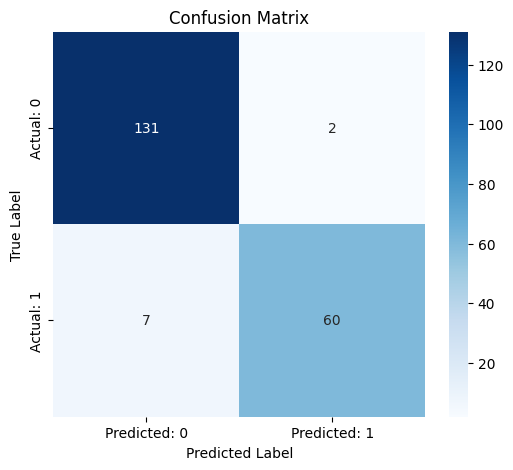

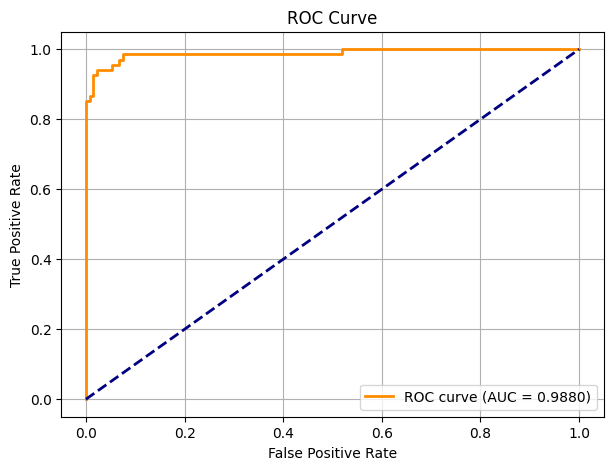

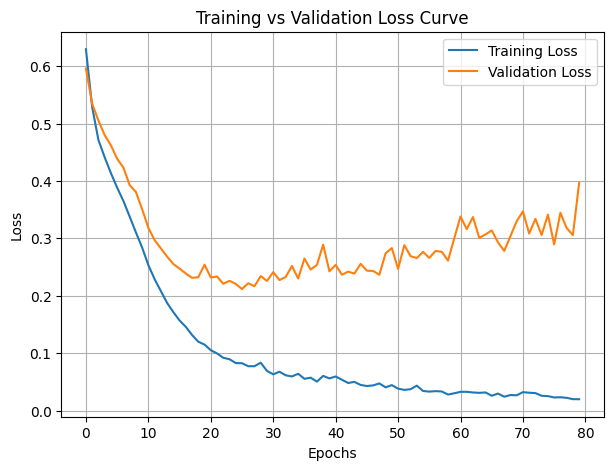

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd


# Modified ANN function with plots
def ann_classification(data, target_col, imp_features, epochs=80, batch_size=16):

    # Select the features and target variable
    X = data[imp_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Scale the data using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Generate the classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    # === Confusion Matrix ===
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted: 0', 'Predicted: 1'],
                yticklabels=['Actual: 0', 'Actual: 1'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # === ROC Curve ===
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # === Training vs Validation Loss Curve ===
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

# Specify the target column
target_column = 'High-Risk Pregnancy'

# Use all features except the target column
imp_features = ['Weight', 'Diastolic Pressure', 'TiTi Tika', 'HRsAG', 'Gestation Period', 'Height', 'Gravida', 'Urine Test Sugar', 'VDRL']

# Apply ANN on the dataset using all features
ann_model = ann_classification(df, target_column, imp_features, epochs=80, batch_size=16)


# With SMOTE

## Applying ANN

### Without Feature Selection

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to Categorical Columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Convert string values to numbers
    label_encoders[col] = le

# Define the ANN function with SMOTE
def ann_classification(data, target_col, features, epochs=80, batch_size=16):
    """
    Perform ANN classification on the dataset using all features and apply SMOTE for data balancing.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - features: List of column names (features) to use for training.
    - epochs: Number of epochs for training the ANN.
    - batch_size: Batch size for training.

    Returns:
    - Classification report and accuracy score.
    """

    # Select the features and target variable
    X = data[features]
    y = data[target_col]

    # Apply SMOTE for oversampling the minority class
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

    # Scale the data using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Specify the target column
target_column = 'High-Risk Pregnancy'

# Use all features except the target column
all_features = df.columns.drop([target_column])

# Apply ANN on the dataset using all features with SMOTE
ann_model = ann_classification(df, target_column, all_features, epochs=80, batch_size=16)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully!
          Name  Age Gravida TiTi Tika Gestation Period Weight Height  \
0    Rituporna   18     1st       1st          38 week  50 kg  5.3''   
1        Moina   25     2nd       2nd          38 week  60 kg  5.2''   
2       Rabeya   20     1st       1st          30 week  55 kg  5.0''   
3       Shorna   22     1st       3rd          35 week  51 kg  5.4''   
4  Tania Akter   20     1st       2nd          30 week  53 kg  5.2''   

   Systolic Pressure  Diastolic Pressure  Anemia  Jaundice Fetal Position  \
0                100                  60       0         0         Normal   
1                100                  70       0         0         Normal   
2                100                  60       0         0         Normal   
3                110                  65       0         0         Normal   
4                100    

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5878 - loss: 0.6783 - val_accuracy: 0.7136 - val_loss: 0.6147
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7608 - loss: 0.5766 - val_accuracy: 0.7324 - val_loss: 0.5214
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4757 - val_accuracy: 0.7793 - val_loss: 0.4543
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8087 - loss: 0.3986 - val_accuracy: 0.8075 - val_loss: 0.4095
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8369 - loss: 0.3556 - val_accuracy: 0.8169 - val_loss: 0.3742
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8575 - loss: 0.3050 - val_accuracy: 0.8310 - val_loss: 0.3453
Epoch 7/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8874 - loss: 0.2580 - val_accuracy: 0.8592 - val_loss: 0.3076
Epoch 8/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9282 - loss: 0.2091 - val_accuracy: 0.8638 - val_loss: 0.2768
Epo

In [ ]:
df

,Name,Age,Gravida,TiTi Tika,Gestation Period,Weight,Height,Systolic Pressure,Diastolic Pressure,Anemia,Jaundice,Fetal Position,Fetal Movements,Fetal Heartbeat,Urine Test Albumin,Urine Test Sugar,VDRL,HRsAG,High-Risk Pregnancy
0,214,18,0,0,10,2,3,100,60,0,0,1,0,3,0,1,0,0,1
1,149,25,1,1,10,9,2,100,70,0,0,1,0,2,0,1,1,0,0
2,198,20,0,0,6,6,0,100,60,0,0,1,0,0,0,1,0,0,1
3,294,22,0,2,8,3,4,110,65,0,0,1,0,2,0,1,1,0,1
4,324,20,0,1,6,5,2,100,55,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,208,22,0,0,0,1,6,90,60,0,0,1,0,4,0,1,1,0,1
994,6,22,0,1,6,0,3,110,80,0,0,0,0,3,0,1,0,0,0
995,196,19,0,2,6,2,2,100,70,0,0,1,0,3,0,1,1,0,1
996,240,30,1,1,6,1,1,90,60,0,0,1,0,2,0,1,0,0,1


### With FS

In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, scale
import numpy as np
from imblearn.over_sampling import SMOTE

#-----------------------Converting Categorical Data into Numerical-------------------
for column in df.select_dtypes(include=['object']):
    df[column], unique_values = df[column].factorize()

# Define target variable
target_column = 'High-Risk Pregnancy'

# Separate features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Apply SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Standardizing the data
X_train = pd.DataFrame(scale(X_train))
X_test = pd.DataFrame(scale(X_test))

# Compute Mutual Information Scores
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_sorted_indices = np.argsort(mi)[::-1]  # Sort in descending order

# Select top 50% features initially
num_features = len(mi_sorted_indices)
best_50_percent_indices = mi_sorted_indices[:num_features // 2]
excluded_features_indices = mi_sorted_indices[num_features // 2:]

# Convert indices to column names
best_features = X_train.columns[best_50_percent_indices].tolist()
excluded_features = X_train.columns[excluded_features_indices].tolist()

# Iterative feature selection process
iterations = 15
for i in range(iterations):
    improved = False
    print(f"Iteration {i+1}:")

    for j in range(len(excluded_features)):
        for k in range(len(best_features)):
            # Swap one excluded feature with an included feature
            temp_best_features = best_features.copy()
            temp_excluded_features = excluded_features.copy()

            feature_to_add = excluded_features[j]
            feature_to_remove = best_features[k]

            temp_best_features.append(feature_to_add)
            temp_best_features.remove(feature_to_remove)

            temp_excluded_features.append(feature_to_remove)
            temp_excluded_features.remove(feature_to_add)

            # Check new feature ranking
            new_mi_scores = mutual_info_classif(X_train[temp_best_features], y_train, random_state=42)
            new_score_sum = np.sum(new_mi_scores)  # Summing MI scores for comparison

            if new_score_sum > np.sum(mi[best_50_percent_indices]):
                best_features = temp_best_features
                excluded_features = temp_excluded_features
                improved = True
                print(f"Updated feature selection by adding {feature_to_add} and removing {feature_to_remove}")
                break  # Exit loop if improvement is found

        if improved:
            break  # Stop if improvement found

    if not improved:
        print("No improvement found in this iteration. Stopping early.")
        break  # Stop iteration if no further improvement

# Display final selected features
print("Final Important Features Based on Rank:")
df.iloc[:, best_features]


Iteration 1:
Updated feature selection by adding 13 and removing 2
Iteration 2:
Updated feature selection by adding 16 and removing 9
Iteration 3:
Updated feature selection by adding 15 and removing 13
Iteration 4:
Updated feature selection by adding 12 and removing 16
Iteration 5:
Updated feature selection by adding 11 and removing 15
Iteration 6:
Updated feature selection by adding 10 and removing 12
Iteration 7:
Updated feature selection by adding 6 and removing 11
Iteration 8:
Updated feature selection by adding 1 and removing 10
Iteration 9:
Updated feature selection by adding 0 and removing 14
Iteration 10:
Updated feature selection by adding 13 and removing 4
Iteration 11:
Updated feature selection by adding 2 and removing 0
Iteration 12:
Updated feature selection by adding 9 and removing 13
Iteration 13:
Updated feature selection by adding 16 and removing 2
Iteration 14:
Updated feature selection by adding 4 and removing 9
Iteration 15:
No improvement found in this iteration. S

,Diastolic Pressure,Weight,Systolic Pressure,TiTi Tika,HRsAG,Height,Age,VDRL,Gestation Period
0,60,0,100,0,0,0,18,0,0
1,70,1,100,1,0,1,25,1,0
2,60,2,100,0,0,2,20,0,1
3,65,3,110,2,0,3,22,1,2
4,55,4,100,1,0,1,20,0,1
...,...,...,...,...,...,...,...,...,...
993,60,11,90,0,0,6,22,1,3
994,80,12,110,1,0,0,22,0,1
995,70,0,100,2,0,1,19,1,1
996,60,11,90,1,0,4,30,0,1


In [ ]:
# SHOWING IMPLEMENTATION OF ANN USING SELECTED FEATURES
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, accuracy_score

# Define the ANN function
def ann_classification(X_train, y_train, X_test, y_test, epochs=80, batch_size=16):

    # Scale the data using StandardScaler (Only Numeric Columns)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Train ANN using selected important features
X_train_selected = X_train.iloc[:, best_features]
X_test_selected = X_test.iloc[:, best_features]

ann_model = ann_classification(X_train_selected, y_train, X_test_selected, y_test, epochs=80, batch_size=16)


Epoch 1/80


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5606 - loss: 0.6884 - val_accuracy: 0.7746 - val_loss: 0.5727
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7660 - loss: 0.5632 - val_accuracy: 0.8028 - val_loss: 0.4566
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7977 - loss: 0.4707 - val_accuracy: 0.8216 - val_loss: 0.3969
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8501 - loss: 0.3893 - val_accuracy: 0.8404 - val_loss: 0.3485
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8546 - loss: 0.3370 - val_accuracy: 0.8685 - val_loss: 0.2943
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8672 - loss: 0.2898 - val_accuracy: 0.8779 - val_loss: 0.2587
Epoch 7/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8846 - loss: 0.2424 - val_accuracy: 0.8826 - val_loss: 0.2335
Epoch 8/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9253 - loss: 0.2025 - val_accuracy: 0.9061 - val_loss: 0.2190
Epo